# Libraries

In [122]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

import statistics
# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [123]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2026\20260402_60Ag_RT_K2SO4-water_H2SO4anolyte

17-Aug-26  04:42 AM    <DIR>          .
18-Apr-26  10:11 AM    <DIR>          ..
13-Aug-26  02:28 PM    <DIR>          .ipynb_checkpoints
22-Apr-26  07:31 PM             1,162 20260402 - Ag60 GDE_RT_K2SO4-water_pH3.csv
17-Aug-26  01:52 AM         1,001,050 20260402 - Ag60 GDE_RT_K2SO4-water_pH3.ipynb
09-Apr-26  12:39 PM             1,142 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_CORRECTED.csv
17-Aug-26  01:52 AM               742 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_Energy Consumption.csv
22-Apr-26  07:32 PM           124,871 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(CO)vsCD_SEM.png
22-Apr-26  07:32 PM           130,787 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(H2)vsCD_SEM.png
22-Apr-26  07:32 PM           107,463 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(O2)vsCD_SEM.png
25-Apr-2

# Load Data

In [124]:
DATE          = "2026-04-02"
Temp_C_median = 21.4          # electrolyte temperature, pH meter [degC]
STEP_MIN      = 20            # length of each current step       [min]
A_cm2         = 10            # geometric electrode area          [cm2]

FILES = {
    "gc_cathode":   "Book_cathode_GC times.xlsx",
    "gc_anode":     "Book_anode_GC times.xlsx",
    "flow_cathode": "K2SO4_RT__60Ag_pH3_20260402_1954_1min.xlsx",
    "flow_anode":   "Anolyte_RT_60Ag_H2SO4_20260402_1953_1min.xlsx",
    "power":        "Power supply_1.csv",
}

In [160]:
Book = "Book_20260402_Ag60 GDE_RT_K2SO4-water_pH3.xlsx"
Book_o2 = "Book_20260402_Ag60 GDE_RT_K2SO4-water_pH3 - O2.xlsx"
Book = pd.read_excel(Book)
Book_o2 = pd.read_excel(Book_o2)
Book.head(3)
Book.drop(['Electrode','Catholyte','Anolyte', 'Membrane', 'area(CH4)',
       'Unnamed: 24', 'Unnamed: 25', 'uGC', 'Unnamed: 27','FE(CH4)', 'Total FE', 'Carbon efficiency'], axis='columns', inplace=True)
Book_o2.drop(['Electrode','Catholyte','Anolyte', 'Membrane', 'area(CO2)', 'area(CH4)',
              'c(CO2)', 'Unnamed: 24', 'Unnamed: 25', 'uGC', 'Unnamed: 27','FE(CH4)', 'Total FE', 'Carbon efficiency'], axis='columns', inplace=True)
Book.columns
Book_o2.columns


Book_cathode_GC = pd.read_excel("Book_cathode_GC times.xlsx")

Book_anode_GC = pd.read_excel("Book_anode_GC times.xlsx")

# Constants and calibration

In [161]:
# ---------------------------------------------------------------------------
# 1) constants and calibration
# ---------------------------------------------------------------------------
F   = 96485                        # Faraday constant             [C/mol]
R   = 8.314                        # ideal-gas constant           [J/(mol K)]
Tk  = Temp_C_median + 273.15       # gas temperature              [K]
Pa  = 101325                       # pressure                     [Pa]
V_m = (R*Tk/Pa)*1000               # molar volume, ideal gas      [L/mol]
z   = {"H2": 2, "CO": 2, "O2": 4}  # electrons per molecule

# wet-to-dry: the meter reads gas saturated with water at the electrolyte
# temperature; only the remaining fraction is product + carrier. Buck equation.
P_SAT = 0.61121*np.exp((18.678 - Temp_C_median/234.5)
                       *(Temp_C_median/(257.14 + Temp_C_median))) * 1000   # Pa
X_H2O = P_SAT / Pa
DRY   = 1 - X_H2O

In [162]:
# Agilent 990 response factors, one calibration per channel.
# Cathode line: H2 quadratic in peak area, CO linear.
a_H2, b_H2 = 3.51e-18, 2.20e-09           # c(H2) = a*p^2 + b*p
a_CO       = 2.30e-08                     # c(CO) = a*p
# Anode line: separate calibration, all linear.  c = k*p/100 -> mole fraction
k = {"H2": 2.66129e-07, "CO": 2.20561e-06,
     "O2": 1.77757e-06, "N2": 2.24463e-06}

q25 = lambda s: s.quantile(.25)
q75 = lambda s: s.quantile(.75)

print(f"V_m   = {V_m:.3f} L/mol at {Temp_C_median} degC")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.169 L/mol at 21.4 degC
p_sat = 2.5490 kPa -> x(H2O) = 2.52 % -> dry factor 0.97484


### Power Supply

In [163]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(10)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,"0,00V","0,00V","0,000A","0,000A","320,00W","0,00W",N/AR,NaN,NaN,On,CV,NaN,02-04-26 16:36
1,"40,00V","2,11V","0,100A","0,102A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:36
2,"40,00V","2,14V","0,100A","0,101A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:37
3,"40,00V","2,15V","0,100A","0,098A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:37
4,"40,00V","2,16V","0,100A","0,099A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:38
5,"40,00V","2,17V","0,100A","0,099A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:38
6,"40,00V","2,17V","0,100A","0,101A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:39
7,"40,00V","2,19V","0,100A","0,102A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:39
8,"40,00V","2,19V","0,100A","0,098A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:40
9,"40,00V","2,20V","0,100A","0,102A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:40


In [164]:
power_sup.groupby("I set", group_keys=True)[["U actual"]].apply(lambda x: x)

U actual
I set              
0,000A 0      0,00V
0,100A 1      2,11V
       2      2,14V
       3      2,15V
       4      2,16V
...             ...
3,000A 315    4,71V
       316    4,78V
       317    4,74V
       318    4,81V
       319    4,76V

[320 rows x 1 columns]

In [165]:
# Fix possible wrong separator in milliseconds (e.g. 16:58:21/004 -> 16:58:21.004)
power_sup["Time"] = power_sup["Time"].astype(str).str.replace(
    r"(\d{2}:\d{2}:\d{2})/(\d+)$",
    r"\1.\2",
    regex=True
)

# Convert Time column
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="mixed",
    dayfirst=True
)

# Convert current and voltage to numbers
power_sup["I actual"] = (
    power_sup["I actual"]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)

power_sup["U actual"] = (
    power_sup["U actual"]
    .astype(str)
    .str.replace("V", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Max current and voltage every 20 min
power_summary = (
    power_sup.resample("20min")
    .agg({
        "I actual": "median",
        "U actual": "median"
    })
    .reset_index()
)

print(power_summary)

                 Time  I actual  U actual
0 2026-04-02 16:20:00    0.1000     2.155
1 2026-04-02 16:40:00    0.0985     2.250
2 2026-04-02 17:00:00    0.2510     2.570
3 2026-04-02 17:20:00    0.4970     3.090
4 2026-04-02 17:40:00    1.0010     3.605
5 2026-04-02 18:00:00    1.4990     3.940
6 2026-04-02 18:20:00    2.0020     4.200
7 2026-04-02 18:40:00    2.4990     4.450
8 2026-04-02 19:00:00    3.0010     4.680


In [166]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2026-04-02 16:20:00    0.1000     2.155
1 2026-04-02 16:40:00    0.0985     2.250
2 2026-04-02 17:00:00    0.2510     2.570
3 2026-04-02 17:20:00    0.4970     3.090
4 2026-04-02 17:40:00    1.0010     3.605
5 2026-04-02 18:00:00    1.4990     3.940
6 2026-04-02 18:20:00    2.0020     4.200
7 2026-04-02 18:40:00    2.4990     4.450


In [167]:
# power_sup["U actual"] = (power_sup["U actual"].str.replace("V", "", regex=False).str.replace(",", ".", regex=False).astype(float))
# power_sup["I set"] = (power_sup["I set"].str.replace("A", "", regex=False).str.replace(",", ".", regex=False).astype(float))

# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [168]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.1000,2.155
0.0985,2.250
0.2510,2.570
0.4970,3.090
1.0010,3.605
1.4990,3.940
2.0020,4.200
2.4990,4.450


In [169]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.1000,2.155,1.000
0.0985,2.250,0.985
0.2510,2.570,2.510
0.4970,3.090,4.970
1.0010,3.605,10.010
1.4990,3.940,14.990
2.0020,4.200,20.020
2.4990,4.450,24.990


In [170]:
# dfcell_voltage[["I actual", "area(H2)", "c(H2)", "area(CO)", "c(CO)"]].head(10)

## FLow rate

In [171]:
flow_rate = "Anolyte_RT_60Ag_H2SO4_20260402_1953_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")

flow_rate_cat = "K2SO4_RT__60Ag_pH3_20260402_1954_1min.xlsx"
flow_rate_cat = pd.read_excel(flow_rate_cat, sheet_name="Process data")

flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2026-04-02 19:53:52.685000,NaN
1,Software version,Aurora 1.2.6,NaN
2,Instrument name,Anolyte_RT_60Ag_H2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:ab:cd:f0,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [172]:
flow_rate = flow_rate.iloc[19:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate_cat = flow_rate_cat.iloc[19:].reset_index(drop=True)
flow_rate_cat = flow_rate_cat.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate_cat

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2026-04-02 14:35:59.971000,50.914146,25.457073
1,2026-04-02 14:37:00.019000,50.113241,25.05662
2,2026-04-02 14:37:59.981000,48.487726,24.243863
3,2026-04-02 14:39:00.029000,48.243689,24.121845
4,2026-04-02 14:39:59.990000,49.726205,24.863102
...,...,...,...
314,2026-04-02 19:50:00.010000,43.705453,21.852726
315,2026-04-02 19:50:59.971000,44.477103,22.238551
316,2026-04-02 19:52:00.019000,46.108123,23.054062
317,2026-04-02 19:52:59.981000,42.448959,21.224479


In [173]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 20min
flow_rate = (
    flow_rate.resample("20min")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

flow_rate_cat["Time (UTC)"] = pd.to_datetime(
    flow_rate_cat["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate_cat = flow_rate_cat.set_index("Time (UTC)")

# Mean current and voltage every 20min
flow_rate_cat = (
    flow_rate_cat.resample("20min")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate_cat)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2026-04-02 14:20:00     48.243689     50.914146      49.497001   
1  2026-04-02 14:40:00     47.922088     51.425497      49.265516   
2  2026-04-02 15:00:00     48.794644     54.490949      51.094302   
3  2026-04-02 15:20:00     49.379256     55.029891      51.886543   
4  2026-04-02 15:40:00     49.711334     56.374585      52.101799   
5  2026-04-02 16:00:00     52.067205     58.061714      54.621267   
6  2026-04-02 16:20:00     55.262782     60.235318      57.550614   
7  2026-04-02 16:40:00     56.455112     64.775951      59.960926   
8  2026-04-02 17:00:00     40.750815     64.734888      58.799437   
9  2026-04-02 17:20:00     43.055244     47.290686      45.080368   
10 2026-04-02 17:40:00     43.923956      45.92413      44.997798   
11 2026-04-02 18:00:00     45.275642     48.428358      46.321856   
12 2026-04-02 18:20:00     45.026571      48.16656      46.584799   
13 2026-04-02 18:40:00     44.3129

### Correction for dry flow

In [174]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.169 L/mol
p_sat = 2.5490 kPa -> x(H2O) = 2.52 % -> dry factor 0.97484


In [175]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY


FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate_cat[c + "_dry"] = flow_rate_cat[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [176]:
print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2026-04-02 14:20:00           0.0           0.0            0.0   
1  2026-04-02 14:40:00           0.0      2.206506       0.351526   
2  2026-04-02 15:00:00      0.545595      1.207793       0.647464   
3  2026-04-02 15:20:00      1.140872      2.529292       1.339437   
4  2026-04-02 15:40:00      2.157447      3.464899       2.428201   
5  2026-04-02 16:00:00      3.189331      4.941414        3.58702   
6  2026-04-02 16:20:00      4.252924      5.689627       4.664635   
7  2026-04-02 16:40:00       5.30972      6.790139       5.692713   
8  2026-04-02 17:00:00       0.02571      6.799082       5.318126   
9  2026-04-02 17:20:00       0.02571       0.02571        0.02571   
10 2026-04-02 17:40:00       0.02571       0.02571        0.02571   
11 2026-04-02 18:00:00       0.02571       0.02571        0.02571   
12 2026-04-02 18:20:00       0.02571      0.036582       0.027054   
13 2026-04-02 18:40:00      0.0365

In [177]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-8].reset_index(drop=True)

dfflow_rate_cat = pd.DataFrame(flow_rate_cat)
dfflow_rate_cat['Current [A]'] = power_summary['I actual']
dfflow_rate_cat['Voltage'] = power_summary['U actual']
dfflow_rate_cat = dfflow_rate_cat.iloc[:-9].reset_index(drop=True)
dfflow_rate_cat


dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2026-04-02 14:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1000,2.155
1,2026-04-02 14:40:00,0.0,2.206506,0.351526,0.255653,0.0,2.150998,0.342683,0.249222,0.0985,2.250
2,2026-04-02 15:00:00,0.545595,1.207793,0.647464,0.564703,0.53187,1.177409,0.631176,0.550497,0.2510,2.570
3,2026-04-02 15:20:00,1.140872,2.529292,1.339437,1.183537,1.112172,2.465664,1.305742,1.153764,0.4970,3.090
4,2026-04-02 15:40:00,2.157447,3.464899,2.428201,2.29517,2.103173,3.377735,2.367116,2.237432,1.0010,3.605
5,2026-04-02 16:00:00,3.189331,4.941414,3.58702,3.425621,3.109099,4.817106,3.496783,3.339445,1.4990,3.940
6,2026-04-02 16:20:00,4.252924,5.689627,4.664635,4.543821,4.145936,5.546497,4.547289,4.429515,2.0020,4.200
7,2026-04-02 16:40:00,5.30972,6.790139,5.692713,5.526359,5.176147,6.619324,5.549505,5.387335,2.4990,4.450


In [178]:
# dfflow_rate

In [179]:
# dfflow_rate.to_csv('20260402_0.6M K2SO4_pH3_flow rate_anode.csv')
# dfflow_rate_cat.to_csv('20260402_0.6M K2SO4_pH3_flow rate_cathode.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 3hr = 10800s <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [180]:
electrode_area = 10/10000 #10cm2 to m2
time = 20*60 #20min

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.1000,2.155,1.000,100.0
0.0985,2.250,0.985,98.5
0.2510,2.570,2.510,251.0


In [181]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.1000,2.155,1.000,100.0,258.600
0.0985,2.250,0.985,98.5,265.950
0.2510,2.570,2.510,251.0,774.084
0.4970,3.090,4.970,497.0,1842.876
1.0010,3.605,10.010,1001.0,4330.326
1.4990,3.940,14.990,1499.0,7087.272
2.0020,4.200,20.020,2002.0,10090.080
2.4990,4.450,24.990,2499.0,13344.660


In [182]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.1000,2.155,1.000,100.0,258.600,0.000072
0.0985,2.250,0.985,98.5,265.950,0.000074
0.2510,2.570,2.510,251.0,774.084,0.000215
0.4970,3.090,4.970,497.0,1842.876,0.000512
1.0010,3.605,10.010,1001.0,4330.326,0.001203
1.4990,3.940,14.990,1499.0,7087.272,0.001969
2.0020,4.200,20.020,2002.0,10090.080,0.002803
2.4990,4.450,24.990,2499.0,13344.660,0.003707


In [183]:
# dfcell_voltage.to_csv('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [186]:
# Book["time_min"] = np.arange(len(Book["area(H2)"]))
# cycle = Book["time_min"] % 8
# run_mask = cycle < 4
# # gas_cols = ["area(H2)", "area(CO2)", "area(CO)", "area(O2)"]
# # Book.loc[~run_mask, gas_cols] = np.nan
# Book.tail(5)

# Book[["Applied current / A", "area(H2)", "c(H2)", "area(CO)", "c(CO)"]].tail(10)

Book["Time_20min"] = np.floor(Book["Duration / h"] / (20/60))

Book = Book[Book["Time_20min"].notna()].copy()



Book_o2["Time_20min"] = np.floor(Book_o2["Duration / h"] / (20/60))
Book_o2 = Book_o2[Book_o2["Time_20min"].notna()].copy()
Book_o2



,Inlet flow rate,Flow rate (ml min-1),Applied current / A,Time,Duration / h,area(H2),area(CO),area(O2),area(N2),c(H2),c(CO),c(O2),FE(H2),FE(CO),Time_20min
0,60,0.000000,0.00,2026-04-02 16:36:20,0.000000,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,60,0.000000,-0.10,2026-04-02 16:36:50,0.008333,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,60,0.000000,-0.25,2026-04-02 16:37:20,0.016667,65292.0,3506543.0,30519923.0,18103619.0,0.000144,0.080803,0.554870,0.0,0.0,0.0
3,60,0.000000,-0.25,2026-04-02 16:37:50,0.025000,67739.0,3562365.0,30831092.0,17752974.0,0.000149,0.082089,0.560686,0.0,0.0,0.0
4,60,0.000000,-0.25,2026-04-02 16:38:20,0.033333,76980.0,3717408.0,31403300.0,17093417.0,0.000169,0.085662,0.570069,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,60,6.558127,-0.50,2026-04-02 19:13:53,2.625833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
316,60,6.742154,-0.50,2026-04-02 19:14:23,2.634167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
317,60,6.742154,-0.50,2026-04-02 19:14:53,2.642500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
318,60,6.767250,-0.50,2026-04-02 19:15:23,2.650833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0


In [187]:
# ---------------------------------------------------------------------------
# 1) which rows are the anode?  The GC alternates cathode / anode,
#    so O2 should appear on every other row.
# ---------------------------------------------------------------------------
print(Book_o2[["area(H2)", "area(CO)", "area(O2)"]].head(10))
print("\nO2 present on even rows:", (Book_o2["area(O2)"].fillna(0).iloc[0::2] > 0).sum(),
      " odd rows:",               (Book_o2["area(O2)"].fillna(0).iloc[1::2] > 0).sum())


print(Book[["area(H2)", "area(CO)"]].head(10))

   area(H2)   area(CO)    area(O2)
0       0.0        0.0         0.0
1       0.0        0.0         0.0
2   65292.0  3506543.0  30519923.0
3   67739.0  3562365.0  30831092.0
4   76980.0  3717408.0  31403300.0
5   84065.0  3788019.0  31812620.0
6   93986.0  3895990.0  32529834.0
7   95936.0  3986141.0  32716941.0
8  102889.0  3955282.0  33288710.0
9  100358.0  4116672.0  33169595.0

O2 present on even rows: 23  odd rows: 22
     area(H2)  area(CO)
0         0.0       0.0
1     21223.0       0.0
2    251318.0       0.0
3      1042.0       0.0
4  10172936.0       0.0
5  10888436.0       0.0
6  19199064.0       0.0
7  20801421.0       0.0
8  25520785.0   97386.0
9  29560585.0  286248.0


In [188]:
# print(Book_o2.columns.tolist())
# print(len(Book_o2))

In [189]:
# --- dfflow_rate: build a minutes axis from the UTC timestamps ---
dfr = dfflow_rate.copy()
dfr["t"] = pd.to_datetime(dfr["Time (UTC)"], errors="coerce")
dfr = dfr.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

T0 = dfr["t"].iloc[0]
dfr["Duration / min"] = (dfr["t"] - T0).dt.total_seconds() / 60

print(dfr[["t", "Duration / min"]].head(10))
print("columns:", dfr.columns.tolist())

                    t  Duration / min
0 2026-04-02 14:20:00             0.0
1 2026-04-02 14:40:00            20.0
2 2026-04-02 15:00:00            40.0
3 2026-04-02 15:20:00            60.0
4 2026-04-02 15:40:00            80.0
5 2026-04-02 16:00:00           100.0
6 2026-04-02 16:20:00           120.0
7 2026-04-02 16:40:00           140.0
columns: ['Time (UTC)', 'Flow_rate_min', 'Flow_rate_max', 'Flow_rate_mean', 'Flow_rate_median', 'Flow_rate_min_dry', 'Flow_rate_max_dry', 'Flow_rate_mean_dry', 'Flow_rate_median_dry', 'Current [A]', 'Voltage', 't', 'Duration / min']


In [190]:
cur = dfr["Current [A]"].abs().round(2)      # adjust the name if it differs
t   = dfr["Duration / min"]

step_id = (cur.diff().abs() > 1e-3).cumsum()
steps = (pd.DataFrame({"step": step_id, "I": cur, "t": t})
           .groupby("step").agg(I=("I", "median"),
                                t_start=("t", "min"), t_end=("t", "max"))
           .reset_index(drop=True))
steps = steps[steps["I"] > 0].reset_index(drop=True)
steps["dur_min"] = steps["t_end"] - steps["t_start"]
print(steps.round(2))

run_min = steps["t_end"].max() - steps["t_start"].min()
print(f"\nrun {run_min:.1f} min, {len(Book_o2)} GC rows "
      f"-> {run_min/max(len(Book_o2)-1, 1):.2f} min per injection")

      I  t_start  t_end  dur_min
0  0.10      0.0   20.0     20.0
1  0.25     40.0   40.0      0.0
2  0.50     60.0   60.0      0.0
3  1.00     80.0   80.0      0.0
4  1.50    100.0  100.0      0.0
5  2.00    120.0  120.0      0.0
6  2.50    140.0  140.0      0.0

run 140.0 min, 320 GC rows -> 0.44 min per injection


In [191]:
print(len(Book), Book.columns.tolist())
print(Book[["area(H2)","area(CO)"]].head(20))
print("rows with a peak:",
      ((Book["area(CO)"].fillna(0)>0)|(Book["area(H2)"].fillna(0)>0)).sum())

320 ['Inlet flow rate', 'Flow rate (ml min-1)', 'Applied current / A', 'Time', 'Duration / h', 'area(H2)', 'area(CO)', 'area(CO2)', 'area(O2)', 'area(N2)', 'c(H2)', 'c(CO)', 'c(CO2)', 'c(O2)', 'FE(H2)', 'FE(CO)', 'Time_20min']
      area(H2)   area(CO)
0          0.0        0.0
1      21223.0        0.0
2     251318.0        0.0
3       1042.0        0.0
4   10172936.0        0.0
5   10888436.0        0.0
6   19199064.0        0.0
7   20801421.0        0.0
8   25520785.0    97386.0
9   29560585.0   286248.0
10  33210954.0   545291.0
11  33801918.0   613752.0
12  40730637.0  2632164.0
13  41219384.0  2776798.0
14  49809031.0  3593448.0
15  52914568.0  3909363.0
16  56570920.0  4208962.0
17  61700452.0  4349147.0
18  73421269.0  4678970.0
19  74629770.0  4720079.0
rows with a peak: 46


In [192]:
for name, df in [("cathode", Book_cathode_GC), ("anode", Book_anode_GC)]:
    print(f"--- {name}: {df.shape} ---")
    print(df.columns.tolist())
    print(df.head(3).to_string())
    print()

print("--- dfflow_rate:", dfflow_rate.shape, "---")
print(dfflow_rate.columns.tolist())
print(dfflow_rate.head(3).to_string())

--- cathode: (48, 6) ---
['Time', 'H2', 'O2', 'N2', 'CH4', 'CO']
       Time        H2      O2    N2  CH4          CO
0  14:24:34  95219579   55710   858  315      101338
1  14:28:05     24876  231675   827  174            
2  14:38:42     21223  208511  1010  137            

--- anode: (47, 6) ---
['Time', 'H2', 'O2', 'N2', 'CH4', 'CO']
       Time     H2        O2        N2  CH4       CO
0  14:31:44  63052  30455852  18143959  192  3495275
1  14:35:13  62142  30448175  18183127  138  3469973
2  14:45:45  65292  30519923  18103619  238  3506543

--- dfflow_rate: (8, 11) ---
['Time (UTC)', 'Flow_rate_min', 'Flow_rate_max', 'Flow_rate_mean', 'Flow_rate_median', 'Flow_rate_min_dry', 'Flow_rate_max_dry', 'Flow_rate_mean_dry', 'Flow_rate_median_dry', 'Current [A]', 'Voltage']
           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry Flow_rate_median_dry  Current [A]  Voltage
0 2026-04-02 14:20:00           0.0 

In [193]:
DATE = "2026-04-02"

##### Give each GC injection the current/voltage/flow of the step it falls in. ######

def attach_steps(gc, steps):
    g = gc.copy()
    g["t"] = pd.to_datetime(DATE + " " + g["Time"].astype(str))
    for c in ["H2", "O2", "N2", "CH4", "CO"]:
        g[c] = pd.to_numeric(g[c], errors="coerce").fillna(0)   # blanks -> 0
    g = g.sort_values("t")

    s = steps.copy()
    s["t"] = pd.to_datetime(s["Time (UTC)"])
    s = s.sort_values("t")

    out = pd.merge_asof(g, s[["t", "Current [A]", "Voltage",
                              "Flow_rate_median_dry", "Flow_rate_mean_dry"]],
                        on="t", direction="backward")     # step start -> forward
    return out.dropna(subset=["Current [A]"])

cath = attach_steps(Book_cathode_GC, dfflow_rate_cat)
an   = attach_steps(Book_anode_GC,   dfflow_rate)

print(cath.groupby("Current [A]").size().rename("cathode injections"))
print(an.groupby("Current [A]").size().rename("anode injections"))
print(f"\ncathode {cath.t.min():%H:%M} - {cath.t.max():%H:%M}   "
      f"anode {an.t.min():%H:%M} - {an.t.max():%H:%M}")

Current [A]
0.0985     3
0.1000     3
0.2510     2
0.4970     4
1.0010     2
1.4990     3
2.0020     3
2.4990    28
Name: cathode injections, dtype: int64
Current [A]
0.0985     3
0.1000     2
0.2510     3
0.4970     2
1.0010     4
1.4990     2
2.0020     3
2.4990    28
Name: anode injections, dtype: int64

cathode 14:24 - 19:50   anode 14:31 - 19:54


In [194]:
RUN_END = pd.Timestamp("2026-04-02 17:16")     # 3.0 A step ends ~17:15 UTC based on power supply

cath = cath[cath["t"] <= RUN_END]
an   = an[an["t"]   <= RUN_END]

print(cath.groupby("Current [A]").size())
print(an.groupby("Current [A]").size())

Current [A]
0.0985    3
0.1000    3
0.2510    2
0.4970    4
1.0010    2
1.4990    3
2.0020    3
2.4990    5
dtype: int64
Current [A]
0.0985    3
0.1000    2
0.2510    3
0.4970    2
1.0010    4
1.4990    2
2.0020    3
2.4990    5
dtype: int64


## Anode

In [195]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
Tk   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
Pa   = 101325       # pressure                           [Pa]
V_m = (R*Tk/Pa)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
# n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

# --- ANODE: no carrier gas, the flow meter reads O2 directly ---
# an["FE_O2"] = (an["Flow_rate_median"]/1000/60 / V_m * 4 * F) / an["Current [A]"] * 100

# anode_sum = (an.groupby("Current [A]")
#                .agg(FE_O2=("FE_O2", "median"),
#                     FE_O2_q25=("FE_O2", lambda s: s.quantile(.25)),
#                     FE_O2_q75=("FE_O2", lambda s: s.quantile(.75)),
#                     V=("Voltage", "median"),
#                     n=("FE_O2", "size")).reset_index())
# anode_sum["FE_O2_err_low"]  = anode_sum.FE_O2 - anode_sum.FE_O2_q25
# anode_sum["FE_O2_err_high"] = anode_sum.FE_O2_q75 - anode_sum.FE_O2

# print(anode_sum.round(2).to_string())

V_m = 24.169 L/mol


In [196]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.1, 0.0985, 0.251, 0.497, 1.001, 1.499, 2.002, 2.499]

In [197]:
# Count injections per step
step = (Book["Duration / h"] // (20/60)).astype(int)

inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[41, 39, 40, 40, 40, 40, 40, 40]

In [198]:
# --- anode: O2 (produced) + H2/CO (crossover from the cathode) -------------
# same uGC response factors, anode flow meter, median + IQR as on the cathode

I_seq = np.repeat(currents, inj_per_step)

# --- uGC response factors (this instrument / this run only) ---
a_H2, b_H2 = 3.51e-18, 2.20e-09      # c(H2) = a*p^2 + b*p
a_CO       = 2.30e-08                # c(CO) = a*p

p_H2a, p_COa = an["H2"], an["CO"]
an["c_H2"] = a_H2 * p_H2a**2 + b_H2 * p_H2a
an["c_CO"] = a_CO * p_COa

Q_AN = an["Flow_rate_median_dry"]          # mL/min


##### FARADAIC EFFICIENCY #################

an["FE_O2"] = (Q_AN/1000/60 / V_m * z["O2"] * F) / an["Current [A]"] * 100
an["FE_H2_anode"] = (an["c_H2"] * Q_AN/1000/60 / V_m * 2 * F) / an["Current [A]"] * 100
an["FE_CO_anode"] = (an["c_CO"] * Q_AN/1000/60 / V_m * 2 * F) / an["Current [A]"] * 100

q25 = lambda s: s.quantile(.25)
q75 = lambda s: s.quantile(.75)

anode_sum = (an.groupby("Current [A]")
               .agg(FE_O2=("FE_O2", "median"),
                    FE_O2_q25=("FE_O2", q25),  FE_O2_q75=("FE_O2", q75),
                    FE_H2=("FE_H2_anode", "median"),
                    FE_H2_q25=("FE_H2_anode", q25), FE_H2_q75=("FE_H2_anode", q75),
                    FE_CO=("FE_CO_anode", "median"),
                    FE_CO_q25=("FE_CO_anode", q25), FE_CO_q75=("FE_CO_anode", q75),
                    V=("Voltage", "median"),
                    n=("FE_O2", "size")).reset_index())

for g in ["FE_O2", "FE_H2", "FE_CO"]:
    anode_sum[g+"_err_low"]  = anode_sum[g]      - anode_sum[g+"_q25"]
    anode_sum[g+"_err_high"] = anode_sum[g+"_q75"] - anode_sum[g]

print(anode_sum.round(3).to_string())

   Current [A]      FE_O2  FE_O2_q25  FE_O2_q75     FE_H2  FE_H2_q25  FE_H2_q75     FE_CO  FE_CO_q25  FE_CO_q75      V  n FE_O2_err_low FE_O2_err_high FE_H2_err_low FE_H2_err_high FE_CO_err_low FE_CO_err_high
0        0.098  67.338854     67.339     67.339  0.005018      0.005      0.005  2.758684      2.737      2.819  2.250  3           0.0            0.0      0.000091       0.000342      0.021614       0.060032
1        0.100        0.0      0.000      0.000       0.0      0.000      0.000       0.0      0.000      0.000  2.155  2           0.0            0.0           0.0            0.0           0.0            0.0
2        0.251   58.37104     58.371     58.371  0.006036      0.006      0.006  2.615249      2.579      2.646  2.570  3           0.0            0.0      0.000319       0.000063      0.036239       0.030258
3        0.497  61.784096     61.784     61.784  0.006908      0.007      0.007  2.867631      2.839      2.896  3.090  2           0.0            0.0      0.000043

In [199]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,V,n,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high
0,0.0985,67.338854,67.338854,67.338854,0.005018,0.004928,0.005360,2.758684,2.737070,2.818717,2.250,3,0.0,0.0,0.000091,0.000342,0.021614,0.060032
1,0.1000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,2.155,2,0.0,0.0,0.0,0.0,0.0,0.0
2,0.2510,58.37104,58.371040,58.371040,0.006036,0.005717,0.006098,2.615249,2.579011,2.645507,2.570,3,0.0,0.0,0.000319,0.000063,0.036239,0.030258
3,0.4970,61.784096,61.784096,61.784096,0.006908,0.006865,0.006951,2.867631,2.838963,2.896298,3.090,2,0.0,0.0,0.000043,0.000043,0.028668,0.028668
4,1.0010,59.488339,59.488339,59.488339,0.006594,0.006562,0.006611,2.747821,2.681691,2.805785,3.605,4,0.0,0.0,0.000032,0.000017,0.066129,0.057964
5,1.4990,59.290995,59.290995,59.290995,0.008051,0.007900,0.008203,2.496077,2.491614,2.500540,3.940,2,0.0,0.0,0.000152,0.000152,0.004463,0.004463
6,2.0020,58.885478,58.885478,58.885478,0.013613,0.012844,0.016515,2.274075,2.246377,2.285774,4.200,3,0.0,0.0,0.000768,0.002903,0.027698,0.011699
7,2.4990,57.375153,57.375153,57.375153,0.029726,0.028109,0.034985,2.293605,2.231992,2.519402,4.450,5,0.0,0.0,0.001617,0.005259,0.061613,0.225797


In [200]:
anode_sum[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
] = dfflow_rate[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
].to_numpy()

In [201]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,...,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.0985,67.338854,67.338854,67.338854,0.005018,0.004928,0.005360,2.758684,2.737070,2.818717,...,0.0,0.0,0.000091,0.000342,0.021614,0.060032,0.0,0.0,0.0,0.0
1,0.1000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.342683,0.0,2.150998,0.249222
2,0.2510,58.37104,58.371040,58.371040,0.006036,0.005717,0.006098,2.615249,2.579011,2.645507,...,0.0,0.0,0.000319,0.000063,0.036239,0.030258,0.631176,0.53187,1.177409,0.550497
3,0.4970,61.784096,61.784096,61.784096,0.006908,0.006865,0.006951,2.867631,2.838963,2.896298,...,0.0,0.0,0.000043,0.000043,0.028668,0.028668,1.305742,1.112172,2.465664,1.153764
4,1.0010,59.488339,59.488339,59.488339,0.006594,0.006562,0.006611,2.747821,2.681691,2.805785,...,0.0,0.0,0.000032,0.000017,0.066129,0.057964,2.367116,2.103173,3.377735,2.237432
5,1.4990,59.290995,59.290995,59.290995,0.008051,0.007900,0.008203,2.496077,2.491614,2.500540,...,0.0,0.0,0.000152,0.000152,0.004463,0.004463,3.496783,3.109099,4.817106,3.339445
6,2.0020,58.885478,58.885478,58.885478,0.013613,0.012844,0.016515,2.274075,2.246377,2.285774,...,0.0,0.0,0.000768,0.002903,0.027698,0.011699,4.547289,4.145936,5.546497,4.429515
7,2.4990,57.375153,57.375153,57.375153,0.029726,0.028109,0.034985,2.293605,2.231992,2.519402,...,0.0,0.0,0.001617,0.005259,0.061613,0.225797,5.549505,5.176147,6.619324,5.387335


## Cathode

In [202]:
cath = cath[cath["t"] > pd.Timestamp("2026-04-02 14:26")] #the cell had barely started. 
# It also carries CO = 101,338 while the two injections after it show blank CO entirely. 
# That reads as residual gas in the line or a purge, not electrolysis.

In [203]:
# --- uGC response factors (this instrument / this run only) ---
a_H2, b_H2 = 3.51e-18, 2.20e-09      # c(H2) = a*p^2 + b*p
a_CO       = 2.30e-08                # c(CO) = a*p

Q_CATH = cath["Flow_rate_median_dry"] 

p_H2 = cath["H2"]
p_CO = cath["CO"]
cath["c_H2"] = a_H2 * p_H2**2 + b_H2 * p_H2
cath["c_CO"] = a_CO * p_CO

# closure check: fraction (~1) or percent (~100)?
print("c_H2 range: %.4g to %.4g" % (cath.c_H2.min(), cath.c_H2.max()))
print("c_CO range: %.4g to %.4g" % (cath.c_CO.min(), cath.c_CO.max()))
print("c_H2 + c_CO median: %.4f" % (cath.c_H2 + cath.c_CO).median())

cath["FE_H2"] = (cath["c_H2"] * Q_CATH/1000/60 / V_m * 2 * F) / cath["Current [A]"] * 100
cath["FE_CO"] = (cath["c_CO"] * Q_CATH/1000/60 / V_m * 2 * F) / cath["Current [A]"] * 100

cath_sum = (cath.groupby("Current [A]")
              .agg(FE_H2=("FE_H2", "median"), FE_CO=("FE_CO", "median"),
                   FE_H2_q25=("FE_H2", lambda s: s.quantile(.25)),
                   FE_H2_q75=("FE_H2", lambda s: s.quantile(.75)),
                   FE_CO_q25=("FE_CO", lambda s: s.quantile(.25)),
                   FE_CO_q75=("FE_CO", lambda s: s.quantile(.75)),
                   V=("Voltage", "median"),
                   n=("FE_H2", "size")).reset_index())
cath_sum["FE_total"] = cath_sum.FE_H2 + cath_sum.FE_CO
print(cath_sum.round(2).to_string())

c_H2 range: 2.292e-06 to 0.2635
c_CO range: 0 to 0.1165
c_H2 + c_CO median: 0.1242
   Current [A]      FE_H2      FE_CO  FE_H2_q25  FE_H2_q75  FE_CO_q25  FE_CO_q75     V  n    FE_total
0         0.10   3.584546        0.0       1.80      75.49       0.00       0.00  2.25  3    3.584546
1         0.10    0.32712        0.0       0.31       0.34       0.00       0.00  2.16  2     0.32712
2         0.25  89.544123        0.0      76.91     102.18       0.00       0.00  2.57  2   89.544123
3         0.50  85.714346   5.977192      75.39      95.26       2.28      10.94  3.09  4   91.691538
4         1.00  58.548064   25.14868      55.68      61.42      17.33      32.97  3.60  2   83.696744
5         1.50  55.605757  38.852449      50.52      57.47      34.44      40.56  3.94  3   94.458206
6         2.00  55.348618  37.132247      52.86      61.17      36.53      38.54  4.20  3   92.480865
7         2.50  70.505462  34.949093      68.41      75.02      34.63      35.76  4.45  5  105.454555

In [204]:
cath_sum

,Current [A],FE_H2,FE_CO,FE_H2_q25,FE_H2_q75,FE_CO_q25,FE_CO_q75,V,n,FE_total
0,0.0985,3.584546,0.0,1.799701,75.488449,0.000000,0.000000,2.250,3,3.584546
1,0.1000,0.32712,0.0,0.314158,0.340081,0.000000,0.000000,2.155,2,0.32712
2,0.2510,89.544123,0.0,76.910124,102.178123,0.000000,0.000000,2.570,2,89.544123
3,0.4970,85.714346,5.977192,75.388190,95.256455,2.275977,10.937752,3.090,4,91.691538
4,1.0010,58.548064,25.14868,55.675352,61.420777,17.329562,32.967798,3.605,2,83.696744
5,1.4990,55.605757,38.852449,50.519005,57.474807,34.437629,40.560289,3.940,3,94.458206
6,2.0020,55.348618,37.132247,52.858839,61.166349,36.533810,38.540232,4.200,3,92.480865
7,2.4990,70.505462,34.949093,68.406205,75.022229,34.634074,35.759183,4.450,5,105.454555


In [205]:
cath_sum[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
] = dfflow_rate_cat[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
].to_numpy()

In [206]:
cath_sum

,Current [A],FE_H2,FE_CO,FE_H2_q25,FE_H2_q75,FE_CO_q25,FE_CO_q75,V,n,FE_total,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.0985,3.584546,0.0,1.799701,75.488449,0.000000,0.000000,2.250,3,3.584546,48.251836,47.030052,49.63333,48.475274
1,0.1000,0.32712,0.0,0.314158,0.340081,0.000000,0.000000,2.155,2,0.32712,48.026174,46.716542,50.131818,47.969354
2,0.2510,89.544123,0.0,76.910124,102.178123,0.000000,0.000000,2.570,2,89.544123,49.808955,47.567147,53.120154,49.747278
3,0.4970,85.714346,5.977192,75.388190,95.256455,2.275977,10.937752,3.090,4,91.691538,50.581265,48.137053,53.645538,50.600238
4,1.0010,58.548064,25.14868,55.675352,61.420777,17.329562,32.967798,3.605,2,83.696744,50.791107,48.460777,54.956404,50.679001
5,1.4990,55.605757,38.852449,50.519005,57.474807,34.437629,40.560289,3.940,3,94.458206,53.247194,50.757383,56.601091,52.953505
6,2.0020,55.348618,37.132247,52.858839,61.166349,36.533810,38.540232,4.200,3,92.480865,56.102849,53.87257,58.720015,55.846669
7,2.4990,70.505462,34.949093,68.406205,75.022229,34.634074,35.759183,4.450,5,105.454555,58.452526,55.034906,63.146422,58.024422


In [207]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,...,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.0985,67.338854,67.338854,67.338854,0.005018,0.004928,0.005360,2.758684,2.737070,2.818717,...,0.0,0.0,0.000091,0.000342,0.021614,0.060032,0.0,0.0,0.0,0.0
1,0.1000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.342683,0.0,2.150998,0.249222
2,0.2510,58.37104,58.371040,58.371040,0.006036,0.005717,0.006098,2.615249,2.579011,2.645507,...,0.0,0.0,0.000319,0.000063,0.036239,0.030258,0.631176,0.53187,1.177409,0.550497
3,0.4970,61.784096,61.784096,61.784096,0.006908,0.006865,0.006951,2.867631,2.838963,2.896298,...,0.0,0.0,0.000043,0.000043,0.028668,0.028668,1.305742,1.112172,2.465664,1.153764
4,1.0010,59.488339,59.488339,59.488339,0.006594,0.006562,0.006611,2.747821,2.681691,2.805785,...,0.0,0.0,0.000032,0.000017,0.066129,0.057964,2.367116,2.103173,3.377735,2.237432
5,1.4990,59.290995,59.290995,59.290995,0.008051,0.007900,0.008203,2.496077,2.491614,2.500540,...,0.0,0.0,0.000152,0.000152,0.004463,0.004463,3.496783,3.109099,4.817106,3.339445
6,2.0020,58.885478,58.885478,58.885478,0.013613,0.012844,0.016515,2.274075,2.246377,2.285774,...,0.0,0.0,0.000768,0.002903,0.027698,0.011699,4.547289,4.145936,5.546497,4.429515
7,2.4990,57.375153,57.375153,57.375153,0.029726,0.028109,0.034985,2.293605,2.231992,2.519402,...,0.0,0.0,0.001617,0.005259,0.061613,0.225797,5.549505,5.176147,6.619324,5.387335


In [208]:
# Agilent 990 response factors, one calibration per channel.
# Cathode line: H2 quadratic in peak area, CO linear.
a_H2, b_H2 = 3.51e-18, 2.20e-09           # c(H2) = a*p^2 + b*p
a_CO       = 2.30e-08                     # c(CO) = a*p
# Anode line: separate calibration, all linear.  c = k*p/100 -> mole fraction
k = {"H2": 2.66129e-07, "CO": 2.20561e-06,
     "O2": 1.77757e-06, "N2": 2.24463e-06}
 
q25 = lambda s: s.quantile(.25)
q75 = lambda s: s.quantile(.75)
 
print(f"V_m   = {V_m:.3f} L/mol at {Temp_C_median} degC")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.169 L/mol at 21.4 degC
p_sat = 2.5490 kPa -> x(H2O) = 2.52 % -> dry factor 0.97484


# Power supply: Delivered current and cell voltage per step

In [209]:
ps = pd.read_csv(FILES["power"], sep=";")
ps["Time"] = ps["Time"].astype(str).str.replace(r"(\d{2}:\d{2}:\d{2})/(\d+)$",
                                                r"\1.\2", regex=True)
ps["Time"] = pd.to_datetime(ps["Time"], format="mixed", dayfirst=True)
for c in ["I actual", "U actual"]:
    ps[c] = (ps[c].astype(str).str.replace("A", "", regex=False)
                              .str.replace("V", "", regex=False)
                              .str.replace(",", ".", regex=False)
                              .str.strip().astype(float))

power_summary = (ps.set_index("Time")
                   .resample(f"{STEP_MIN}min")
                   .agg({"I actual": "median", "U actual": "median"})
                   .reset_index())
power_summary = power_summary.iloc[1:].reset_index(drop=True)   # after 16 h
power_summary.rename(columns={"I actual": "Current [A]", "U actual": "V"})
power_summary

,Time,I actual,U actual
0,2026-04-02 16:40:00,0.0985,2.250
1,2026-04-02 17:00:00,0.2510,2.570
2,2026-04-02 17:20:00,0.4970,3.090
3,2026-04-02 17:40:00,1.0010,3.605
4,2026-04-02 18:00:00,1.4990,3.940
5,2026-04-02 18:20:00,2.0020,4.200
6,2026-04-02 18:40:00,2.4990,4.450
7,2026-04-02 19:00:00,3.0010,4.680


# Flow meters (cat and an): one table per compartment, resample to the step grid and corrected to a dry basis (humidified)

In [210]:
def load_flow(path, n_trim):
    d = pd.read_excel(path, sheet_name="Process data").iloc[19:].reset_index(drop=True)
    d = d.rename(columns={"Unnamed: 0": "Time (UTC)",
                          "Unnamed: 1": "Gas flow rate [ml/min]",
                          "Unnamed: 2": "Specific gas production [ml/min/l]"})
    d["Time (UTC)"] = pd.to_datetime(d["Time (UTC)"], format="%d.%m.%Y %H:%M:%S.%f")
    d = (d.set_index("Time (UTC)")
           .resample(f"{STEP_MIN}min")
           .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"),
                Flow_rate_max=("Gas flow rate [ml/min]", "max"),
                Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
                Flow_rate_median=("Gas flow rate [ml/min]", "median"))
           .reset_index())
    for c in ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]:
        d[c + "_dry"] = d[c] * DRY
    d["Current [A]"] = power_summary["I actual"]
    d["Voltage"]     = power_summary["U actual"]
    return d.iloc[:n_trim].reset_index(drop=True)

flow_an   = load_flow(FILES["flow_anode"],   -8)
flow_cath = load_flow(FILES["flow_cathode"], -9)

print("\nstep grid (both meters should agree):")
print(pd.concat([flow_cath[["Time (UTC)", "Current [A]"]],
                 flow_an[["Current [A]"]].add_suffix("_an")], axis=1).to_string())


step grid (both meters should agree):
           Time (UTC)  Current [A]  Current [A]_an
0 2026-04-02 14:20:00       0.0985          0.0985
1 2026-04-02 14:40:00       0.2510          0.2510
2 2026-04-02 15:00:00       0.4970          0.4970
3 2026-04-02 15:20:00       1.0010          1.0010
4 2026-04-02 15:40:00       1.4990          1.4990
5 2026-04-02 16:00:00       2.0020          2.0020
6 2026-04-02 16:20:00       2.4990          2.4990
7 2026-04-02 16:40:00       3.0010          3.0010


# Attach each GC injection to the step it falls in "Time (UTC)"

 is the START of a step, so the join is backward (bottom-top)

In [211]:
def attach_steps(gc_path, steps):
    g = pd.read_excel(gc_path)
    g["t"] = pd.to_datetime(DATE + " " + g["Time"].astype(str))
    for c in ["H2", "O2", "N2", "CH4", "CO"]:
        if c in g:
            g[c] = pd.to_numeric(g[c], errors="coerce").fillna(0)
    s = steps.copy()
    s["t"] = pd.to_datetime(s["Time (UTC)"])
    out = pd.merge_asof(g.sort_values("t"),
                        s.sort_values("t")[["t", "Current [A]", "Voltage",
                                            "Flow_rate_median_dry",
                                            "Flow_rate_mean_dry"]],
                        on="t", direction="backward")
    return out.dropna(subset=["Current [A]"])

cath = attach_steps(FILES["gc_cathode"], flow_cath)
an   = attach_steps(FILES["gc_anode"],   flow_an)

# electrolysis ended ~17:15 UTC; later injections were taken with the cell off
RUN_END = pd.Timestamp(f"{DATE} 17:20")
cath = cath[cath["t"] <= RUN_END].copy()
an   = an[an["t"]   <= RUN_END].copy()

# first cathode injection (14:24) is a start-up artefact: H2 four orders of
# magnitude above the two injections that follow inside the same step
cath = cath[cath["t"] > pd.Timestamp(f"{DATE} 14:26")].copy()

print(f"\ninjections kept: cathode {len(cath)}, anode {len(an)}")


injections kept: cathode 25, anode 24


# Cathode: FE(CO) and FE(H2)

Only H2 and CO are calibrated on this channel, so the stream itself does
not close; the balance below is on charge, not composition.

In [212]:
cath["c_H2"] = a_H2 * cath["H2"]**2 + b_H2 * cath["H2"]
cath["c_CO"] = a_CO * cath["CO"]

for g in ["H2", "CO"]:
    cath[f"FE_{g}"] = (cath[f"c_{g}"] * cath["Flow_rate_median_dry"]/1000/60
                       / V_m * z[g] * F) / cath["Current [A]"] * 100

cath_sum = (cath.groupby("Current [A]")
              .agg(FE_CO=("FE_CO", "median"),
                   FE_CO_q25=("FE_CO", q25), FE_CO_q75=("FE_CO", q75),
                   FE_H2=("FE_H2", "median"),
                   FE_H2_q25=("FE_H2", q25), FE_H2_q75=("FE_H2", q75),
                   area_H2=("H2", "median"), area_CO=("CO", "median"),
                   Q_dry=("Flow_rate_median_dry", "median"),
                   V=("Voltage", "median"),
                   n=("FE_CO", "size")).reset_index())

cath_sum["FE_total"] = cath_sum.FE_CO + cath_sum.FE_H2
for g in ["FE_CO", "FE_H2"]:
    cath_sum[g+"_err_low"]  = (cath_sum[g] - cath_sum[g+"_q25"]).clip(lower=0)
    cath_sum[g+"_err_high"] = (cath_sum[g+"_q75"] - cath_sum[g]).clip(lower=0)

print("\nCATHODE")
print(cath_sum[["Current [A]", "area_H2", "area_CO", "Q_dry", "V",
                "FE_CO", "FE_H2", "FE_total", "n"]].round(3).to_string(index=False))


CATHODE
 Current [A]    area_H2   area_CO      Q_dry     V      FE_CO      FE_H2   FE_total  n
       0.098    23049.5       0.0  48.475274 2.250        0.0   0.332101   0.332101  2
       0.251   251318.0       0.0  47.969354 2.570        0.0   1.406684   1.406684  3
       0.497 15043750.0       0.0  49.747278 3.090        0.0  45.222485  45.222485  2
       1.001 27540685.0  191817.0  50.600238 3.605   2.967697  42.557473  45.525169  4
       1.499 37266277.5 1622958.0  50.679001 3.940  16.793748   39.09714  55.890888  2
       2.002 49809031.0 3593448.0  52.953505 4.200  29.090819   41.63488  70.725699  3
       2.499 61700452.0 4349147.0  55.846669 4.450  29.747403   44.34091  74.088312  3
       3.001 93180749.0 4974870.0  58.024422 4.680  29.440183  60.592086   90.03227  6


# Anode: FE(O2) and stream compositions

Under strongly acidic conditions on a DSA, O2 evolution is the only accessible anodic reaction. Any N2 is therefore air ingress into the anolyte loop, and any H2 or CO has crossed the membrane from the cathode. The meter reads the WHOLE stream, so the O2 rate is c(O2)*Q, not Q.

In [213]:
an["c_H2"] = a_H2 * an["H2"]**2 + b_H2 * an["H2"]
for g in ["CO", "O2", "N2"]:
    an[f"c_{g}"] = k[g] * an[g] / 100

an["normalisation"] = an[["c_H2", "c_CO", "c_O2", "c_N2"]].sum(axis=1)
for g in ["O2", "N2", "CO", "H2"]:
    an[f"{g}_vol%"] = 100 * an[f"c_{g}"] / an["normalisation"]

# O2 purity: oxygen as a percentage of the whole anode stream, closure-normalised
an["O2_purity"] = an["O2_vol%"]

Q_AN = an["Flow_rate_median_dry"]

an["FE_O2"] = (an["c_O2"] * Q_AN/1000/60 / V_m * z["O2"] * F) / an["Current [A]"] * 100
an["XO_CO"] = (an["c_CO"] * Q_AN/1000/60 / V_m * z["CO"] * F) / an["Current [A]"] * 100
an["XO_H2"] = (an["c_H2"] * Q_AN/1000/60 / V_m * z["H2"] * F) / an["Current [A]"] * 100

anode_sum = (an.groupby("Current [A]")
               .agg(FE_O2=("FE_O2", "median"),
                    FE_O2_q25=("FE_O2", q25), FE_O2_q75=("FE_O2", q75),
                    O2_vol=("O2_vol%", "median"), N2_vol=("N2_vol%", "median"),
                    CO_vol=("CO_vol%", "median"), H2_vol=("H2_vol%", "median"),
                    XO_CO=("XO_CO", "median"), XO_H2=("XO_H2", "median"),
                    normalisation=("normalisation", "median"),
                    Q_dry=("Flow_rate_median_dry", "median"),
                    V=("Voltage", "median"),
                    
                    O2_purity=("O2_purity", "median"),
                    O2_purity_q25=("O2_purity", q25),
                    O2_purity_q75=("O2_purity", q75),
                    
                    n=("FE_O2", "size")).reset_index())

anode_sum["FE_O2_err_low"]  = (anode_sum.FE_O2 - anode_sum.FE_O2_q25).clip(lower=0)
anode_sum["FE_O2_err_high"] = (anode_sum.FE_O2_q75 - anode_sum.FE_O2).clip(lower=0)

print("\nANODE   (normalisation should sit near 1.00)")
print(anode_sum[["Current [A]", "normalisation", "Q_dry", "V",
                 "O2_vol", "N2_vol", "CO_vol", "H2_vol",
                 "FE_O2", "XO_CO", "n"]].round(3).to_string(index=False))


ANODE   (normalisation should sit near 1.00)
 Current [A]  normalisation     Q_dry     V  O2_vol  N2_vol  CO_vol  H2_vol      FE_O2     XO_CO  n
       0.098          1.026       0.0 2.250  52.761  39.739   7.487   0.013        0.0       0.0  2
       0.251          1.025  0.249222 2.570  53.454  38.867   7.664   0.015   14.48251  1.038163  3
       0.497          1.016  0.550497 3.090  56.923  34.598   8.459   0.020  17.046033  1.266576  3
       1.001          1.005  1.153764 3.605  58.755  32.368   8.855   0.022  18.119449  1.365358  2
       1.499          0.997  2.237432 3.940  58.058  33.149   8.883   0.022  22.994424  1.759631  4
       2.002          0.995  3.339445 4.200  54.613  37.243   8.117   0.027  24.118058  1.792241  2
       2.499          0.995  4.429515 4.450  51.382  41.052   7.441   0.046  24.122748  1.747043  3
       3.001          0.985  5.387335 4.680  52.881  39.228   7.786   0.105  24.878346  1.831555  5


In [214]:
# anode_sum

In [215]:
print("\nANODE GAS PURITY (vol%, Normalised)")
print(anode_sum[["Current [A]", "O2_purity", "N2_vol", "CO_vol", "H2_vol",
                 "normalisation", "n"]].round(2).to_string(index=False))


ANODE GAS PURITY (vol%, Normalised)
 Current [A]  O2_purity  N2_vol  CO_vol  H2_vol  normalisation  n
        0.10      52.76   39.74    7.49    0.01           1.03  2
        0.25      53.45   38.87    7.66    0.01           1.03  3
        0.50      56.92   34.60    8.46    0.02           1.02  3
        1.00      58.76   32.37    8.85    0.02           1.01  2
        1.50      58.06   33.15    8.88    0.02           1.00  4
        2.00      54.61   37.24    8.12    0.03           0.99  2
        2.50      51.38   41.05    7.44    0.05           1.00  3
        3.00      52.88   39.23    7.79    0.11           0.98  5


# Energy consumption per step

In [216]:
for df in (cath_sum, anode_sum):
    df["EC_kWh"] = df["Current [A]"] * df["V"] * STEP_MIN*60 / 3.6e6 #joules to kWh

print(f"\ntotal cell energy over the run: {cath_sum['EC_kWh'].sum():.4f} kWh")


total cell energy over the run: 0.0152 kWh


In [217]:
df

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,O2_vol,N2_vol,CO_vol,H2_vol,XO_CO,XO_H2,normalisation,Q_dry,V,O2_purity,O2_purity_q25,O2_purity_q75,n,FE_O2_err_low,FE_O2_err_high,EC_kWh
0,0.0985,0.0,0.000000,0.000000,52.760861,39.738771,7.486944,0.013424,0.0,0.0,1.025961,0.0,2.250,52.760861,52.755187,52.766534,2,0.0,0.0,0.000074
1,0.2510,14.48251,14.409427,14.616904,53.454498,38.867313,7.663652,0.014537,1.038163,0.001969,1.025254,0.249222,2.570,53.454498,53.156319,53.982262,3,0.073084,0.134394,0.000215
2,0.4970,17.046033,16.858119,17.095056,56.922595,34.597976,8.459071,0.020358,1.266576,0.003048,1.015837,0.550497,3.090,56.922595,56.225805,57.182049,3,0.187914,0.049023,0.000512
3,1.0010,18.119449,18.103211,18.135687,58.755200,32.367819,8.854739,0.022243,1.365358,0.00343,1.005310,1.153764,3.605,58.755200,58.696353,58.814048,2,0.016238,0.016238,0.001203
4,1.4990,22.994424,22.733904,23.227535,58.058180,33.148778,8.882929,0.022260,1.759631,0.004403,0.997284,2.237432,3.940,58.058180,57.512753,58.457858,4,0.26052,0.233111,0.001969
5,2.0020,24.118058,24.026462,24.209655,54.613208,37.242732,8.116759,0.027302,1.792241,0.006028,0.994759,3.339445,4.200,54.613208,54.410771,54.815645,2,0.091597,0.091597,0.002803
6,2.4990,24.122748,23.921287,24.289026,51.382427,41.051998,7.440570,0.046458,1.747043,0.010905,0.995454,4.429515,4.450,51.382427,50.935082,51.729701,3,0.201461,0.166278,0.003707
7,3.0010,24.878346,24.575793,26.430836,52.880787,39.227769,7.786213,0.105231,1.831555,0.024754,0.984690,5.387335,4.680,52.880787,52.070694,56.753733,5,0.302553,1.55249,0.004682


# Both electrodes side by side. Not summer - two separate balances

In [218]:
both = (cath_sum[["Current [A]", "V", "EC_kWh", "FE_CO", "FE_H2", "FE_total"]]
        .merge(anode_sum[["Current [A]", "FE_O2", "O2_vol", "N2_vol", "XO_CO"]],
               on="Current [A]", how="outer")
        .sort_values("Current [A]"))
both["J"] = (both["Current [A]"] * 1000).round().astype(int)

print("\nBOTH ELECTRODES")
print(both[["J", "Current [A]", "V", "FE_CO", "FE_H2", "FE_total",
            "FE_O2", "O2_vol", "N2_vol", "XO_CO"]].round(2).to_string(index=False))


BOTH ELECTRODES
   J  Current [A]    V      FE_CO      FE_H2   FE_total      FE_O2  O2_vol  N2_vol     XO_CO
  98         0.10 2.25        0.0   0.332101   0.332101        0.0   52.76   39.74       0.0
 251         0.25 2.57        0.0   1.406684   1.406684   14.48251   53.45   38.87  1.038163
 497         0.50 3.09        0.0  45.222485  45.222485  17.046033   56.92   34.60  1.266576
1001         1.00 3.60   2.967697  42.557473  45.525169  18.119449   58.76   32.37  1.365358
1499         1.50 3.94  16.793748   39.09714  55.890888  22.994424   58.06   33.15  1.759631
2002         2.00 4.20  29.090819   41.63488  70.725699  24.118058   54.61   37.24  1.792241
2499         2.50 4.45  29.747403   44.34091  74.088312  24.122748   51.38   41.05  1.747043
3001         3.00 4.68  29.440183  60.592086   90.03227  24.878346   52.88   39.23  1.831555


In [219]:
# cath_sum.to_csv("20260402_0.6M K2SO4_pH3_cathode.csv", index=False)
# anode_sum.to_csv("20260402_0.6M K2SO4_pH3_anode.csv",  index=False)

# Plots

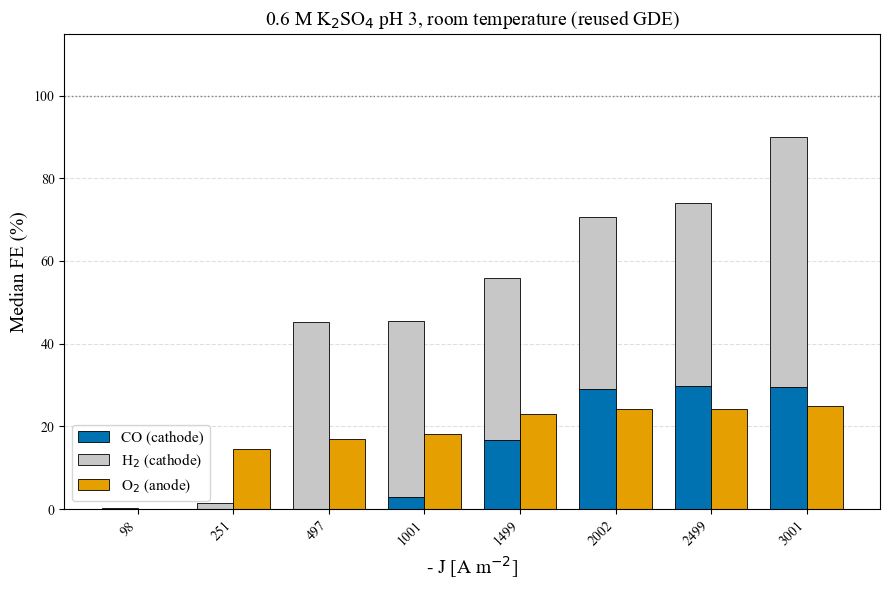

In [220]:
cCO, cH2, cO2 = "#0072B2", "#C7C7C7", "#E69F00"
b = both.dropna(subset=["FE_CO", "FE_O2"])
x, w = np.arange(len(b)), 0.38

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - w/2, b["FE_CO"], w, color=cCO, edgecolor="black", lw=0.6, label="CO (cathode)")
ax.bar(x - w/2, b["FE_H2"], w, bottom=b["FE_CO"], color=cH2,
       edgecolor="black", lw=0.6, label=r"H$_2$ (cathode)")
ax.bar(x + w/2, b["FE_O2"], w, color=cO2, edgecolor="black", lw=0.6, label=r"O$_2$ (anode)")

ax.axhline(100, ls=":", color="grey", lw=1)
ax.set_xticks(x); ax.set_xticklabels(b["J"], rotation=45, ha="right")
ax.set_xlabel(r"- J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Median FE (%)", fontsize=14)
ax.set_title("0.6 M K$_2$SO$_4$ pH 3, room temperature (reused GDE)", fontsize=14)
ax.set_ylim(0, 115)
ax.grid(axis="y", ls="--", alpha=0.4); ax.set_axisbelow(True)
ax.legend(fontsize=11)
plt.tight_layout()
# plt.savefig("20260402_cat-anode_FE_CO and O2.png", dpi=300)
plt.show()

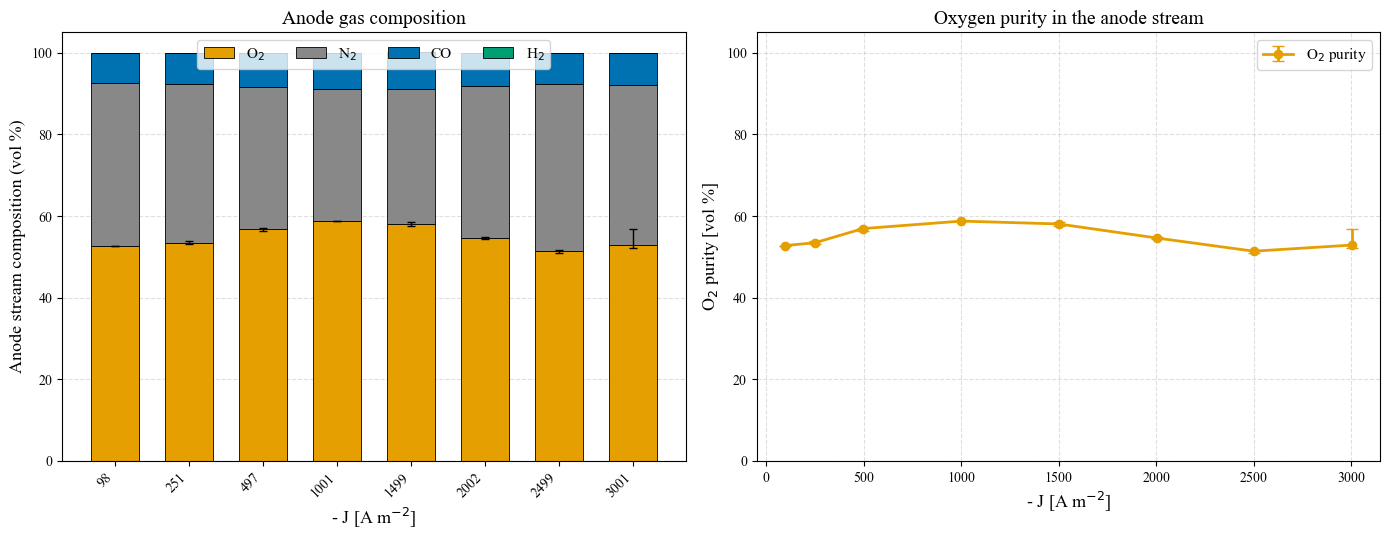

In [221]:
# ---------------------------------------------------------------------------
# 10) anode gas composition vs current density
#     Left : stacked composition, median with IQR whisker at each segment top.
#     Right: O2 purity alone, where the spread is readable.
#     Composition is closure-normalised, so the stack sums to 100 % by
#     construction; the `closure` column reports the un-normalised sum.
# ---------------------------------------------------------------------------
comp = anode_sum.copy()
comp["J"] = (comp["Current [A]"] * 1000).round().astype(int)
xa = np.arange(len(comp))

cols = {"O2_purity": ("#E69F00", r"O$_2$"),
        "N2_vol":    ("#888888", r"N$_2$"),
        "CO_vol":    ("#0072B2", "CO"),
        "H2_vol":    ("#009E73", r"H$_2$")}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- left: stacked composition -------------------------------------------
bottom = np.zeros(len(comp))
for c, (col, lab) in cols.items():
    axL.bar(xa, comp[c], 0.65, bottom=bottom, color=col,
            edgecolor="black", lw=0.6, label=lab)
    bottom += comp[c].values
    # whisker sits at the cumulative top of this segment
    if f"{c}_q25" in comp.columns and f"{c}_q75" in comp.columns:
        axL.errorbar(xa, bottom,
                     yerr=np.vstack([(comp[c] - comp[f"{c}_q25"]).clip(lower=0),
                                     (comp[f"{c}_q75"] - comp[c]).clip(lower=0)]),
                     fmt="none", ecolor="black", capsize=3, lw=1, zorder=5)

axL.set_xticks(xa); axL.set_xticklabels(comp["J"], rotation=45, ha="right")
axL.set_xlabel(r"- J [A m$^{-2}$]", fontsize=13)
axL.set_ylabel("Anode stream composition (vol %)", fontsize=13)
axL.set_title("Anode gas composition", fontsize=14)
axL.set_ylim(0, 105)
axL.grid(axis="y", ls="--", alpha=0.4); axL.set_axisbelow(True)
axL.legend(fontsize=11, ncol=4, loc="upper center")

# ---- right: O2 purity with IQR -------------------------------------------
axR.errorbar(comp["J"], comp["O2_purity"],
             yerr=np.vstack([(comp["O2_purity"] - comp["O2_purity_q25"]).clip(lower=0),
                             (comp["O2_purity_q75"] - comp["O2_purity"]).clip(lower=0)]),
             marker="o", color="#E69F00", lw=2, capsize=4, label=r"O$_2$ purity")
axR.set_xlabel(r"- J [A m$^{-2}$]", fontsize=13)
axR.set_ylabel(r"O$_2$ purity [vol %]", fontsize=13)
axR.set_title("Oxygen purity in the anode stream", fontsize=14)
axR.set_ylim(0, 105)
axR.grid(ls="--", alpha=0.4)
axR.legend(fontsize=11)

plt.tight_layout()
# plt.savefig("20260402_anode_composition_purity.png", dpi=300)
plt.show()

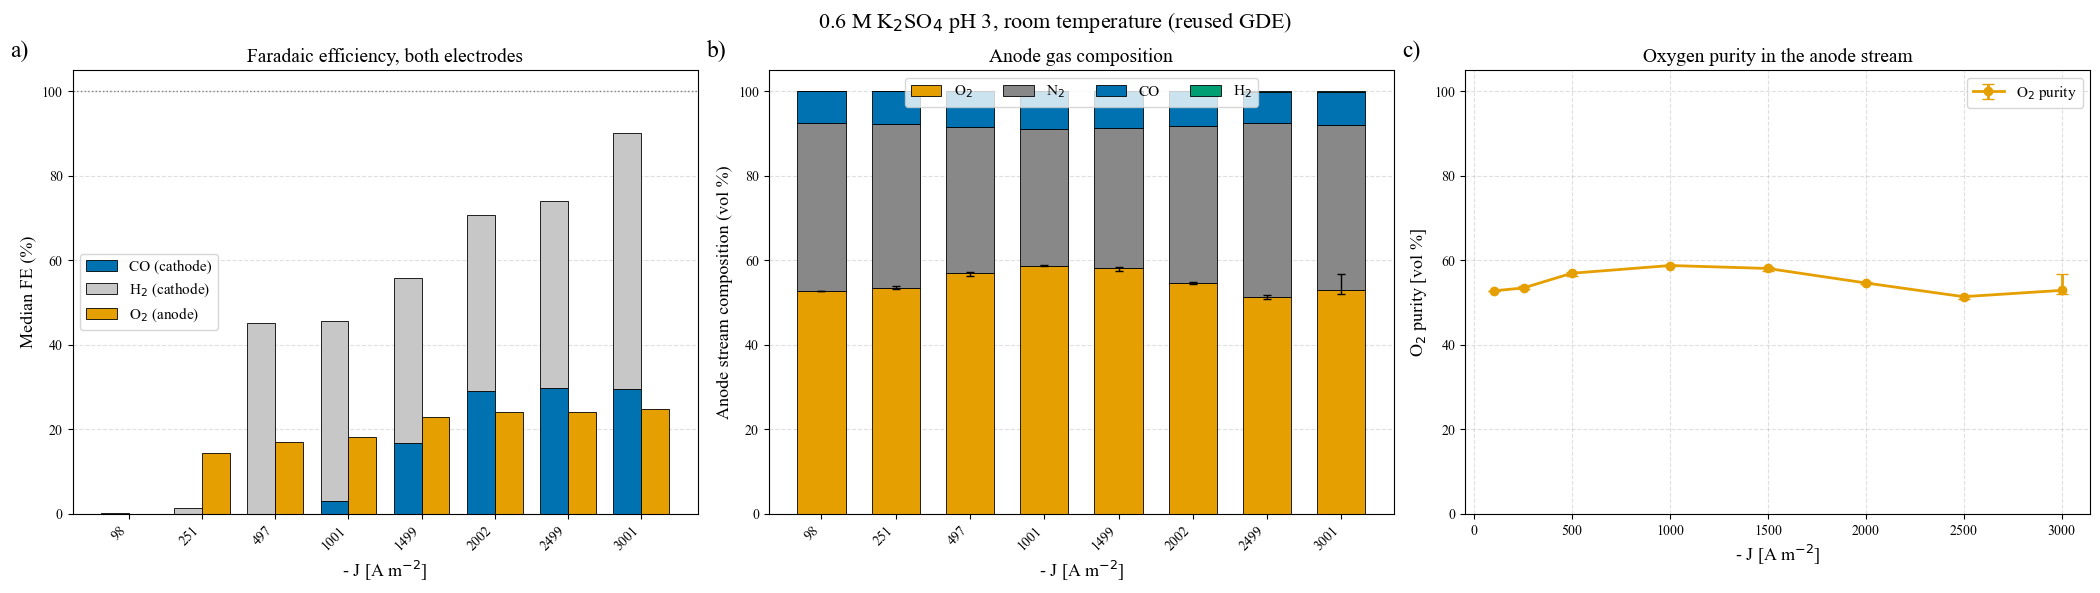

In [224]:
# ===========================================================================
# 2026-04-02, 0.6 M K2SO4 pH 3, room temperature (reused GDE)
#   a) cathode FE(CO)+FE(H2) stacked, anode FE(O2) alongside
#   b) anode gas composition, closure-normalised, median with IQR
#   c) O2 purity vs current density
# ===========================================================================
cCO, cH2, cO2, cN2 = "#0072B2", "#C7C7C7", "#E69F00", "#888888"

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

# ---- a) FE, cathode stacked vs anode --------------------------------------
b = both.dropna(subset=["FE_CO", "FE_O2"])
x, w = np.arange(len(b)), 0.38

ax1.bar(x - w/2, b["FE_CO"], w, color=cCO, edgecolor="black", lw=0.6,
        label="CO (cathode)")
ax1.bar(x - w/2, b["FE_H2"], w, bottom=b["FE_CO"], color=cH2,
        edgecolor="black", lw=0.6, label=r"H$_2$ (cathode)")
ax1.bar(x + w/2, b["FE_O2"], w, color=cO2, edgecolor="black", lw=0.6,
        label=r"O$_2$ (anode)")

ax1.axhline(100, ls=":", color="grey", lw=1)
ax1.set_xticks(x); ax1.set_xticklabels(b["J"], rotation=45, ha="right")
ax1.set_xlabel(r"- J [A m$^{-2}$]", fontsize=13)
ax1.set_ylabel("Median FE (%)", fontsize=13)
ax1.set_title("Faradaic efficiency, both electrodes", fontsize=14)
ax1.set_ylim(0, 105)
ax1.grid(axis="y", ls="--", alpha=0.4); ax1.set_axisbelow(True)
ax1.legend(fontsize=11)

# ---- b) anode composition, stacked ----------------------------------------
# closure-normalised, so the stack sums to 100 % by construction; the
# `closure` column carries the un-normalised sum.
comp = anode_sum.copy()
comp["J"] = (comp["Current [A]"] * 1000).round().astype(int)
xa = np.arange(len(comp))

cols = {"O2_purity": (cO2, r"O$_2$"),
        "N2_vol":    (cN2, r"N$_2$"),
        "CO_vol":    (cCO, "CO"),
        "H2_vol":    ("#009E73", r"H$_2$")}

bottom = np.zeros(len(comp))
for gcol, (col, lab) in cols.items():
    ax2.bar(xa, comp[gcol], 0.65, bottom=bottom, color=col,
            edgecolor="black", lw=0.6, label=lab)
    bottom += comp[gcol].values
    if f"{gcol}_q25" in comp.columns and f"{gcol}_q75" in comp.columns:
        ax2.errorbar(xa, bottom,
                     yerr=np.vstack([(comp[gcol] - comp[f"{gcol}_q25"]).clip(lower=0),
                                     (comp[f"{gcol}_q75"] - comp[gcol]).clip(lower=0)]),
                     fmt="none", ecolor="black", capsize=3, lw=1, zorder=5)

ax2.set_xticks(xa); ax2.set_xticklabels(comp["J"], rotation=45, ha="right")
ax2.set_xlabel(r"- J [A m$^{-2}$]", fontsize=13)
ax2.set_ylabel("Anode stream composition (vol %)", fontsize=13)
ax2.set_title("Anode gas composition", fontsize=14)
ax2.set_ylim(0, 105)
ax2.grid(axis="y", ls="--", alpha=0.4); ax2.set_axisbelow(True)
ax2.legend(fontsize=11, ncol=4, loc="upper center")

# ---- c) O2 purity ---------------------------------------------------------
ax3.errorbar(comp["J"], comp["O2_purity"],
             yerr=np.vstack([(comp["O2_purity"] - comp["O2_purity_q25"]).clip(lower=0),
                             (comp["O2_purity_q75"] - comp["O2_purity"]).clip(lower=0)]),
             marker="o", color=cO2, lw=2, capsize=4, label=r"O$_2$ purity")
ax3.set_xlabel(r"- J [A m$^{-2}$]", fontsize=13)
ax3.set_ylabel(r"O$_2$ purity [vol %]", fontsize=13)
ax3.set_title("Oxygen purity in the anode stream", fontsize=14)
ax3.set_ylim(0, 105)
ax3.grid(ls="--", alpha=0.4)
ax3.legend(fontsize=11)

for ax, letter in zip((ax1, ax2, ax3), "abc"):
    ax.text(-0.10, 1.03, f"{letter})", transform=ax.transAxes, fontsize=17)

fig.suptitle("0.6 M K$_2$SO$_4$ pH 3, room temperature (reused GDE)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
# plt.savefig("20260402_FE_composition_purity.png", dpi=300)
plt.show()

# Export

In [109]:
# ---------------------------------------------------------------------------
# 11) export
# ---------------------------------------------------------------------------
OUT = {
    # per-step summaries
    "20260402_0.6M K2SO4_pH3_cathode.csv":          cath_sum,
    "20260402_0.6M K2SO4_pH3_anode.csv":            anode_sum,
    # flow-meter tables, resampled to the 20 min grid, wet and dry
    "20260402_0.6M K2SO4_pH3_flow rate_anode.csv":   flow_an,
    "20260402_0.6M K2SO4_pH3_flow rate_cathode.csv": flow_cath,
    # per-injection data behind the summaries
    "20260402_0.6M K2SO4_pH3_cathode_injections.csv": cath,
    "20260402_0.6M K2SO4_pH3_anode_injections.csv":   an,
    # both electrodes side by side
    "20260402_0.6M K2SO4_pH3_combined.csv":           both,
}

for name, df in OUT.items():
    df.to_csv(name, index=False)
    print(f"{name:52} {df.shape[0]:>4} rows x {df.shape[1]:>3} cols")

20260402_0.6M K2SO4_pH3_cathode.csv                     8 rows x  18 cols
20260402_0.6M K2SO4_pH3_anode.csv                       8 rows x  20 cols
20260402_0.6M K2SO4_pH3_flow rate_anode.csv             8 rows x  11 cols
20260402_0.6M K2SO4_pH3_flow rate_cathode.csv           8 rows x  11 cols
20260402_0.6M K2SO4_pH3_cathode_injections.csv         25 rows x  15 cols
20260402_0.6M K2SO4_pH3_anode_injections.csv           24 rows x  24 cols
20260402_0.6M K2SO4_pH3_combined.csv                    8 rows x  11 cols
